[Module 3 Homework](https://colab.research.google.com/github/Jaguar838/stock-markets-analytics-zoomcamp/blob/main/HW/2025/hw-03/hw-03.ipynb)

In [ ]:
# IMPORTS
import numpy as np
import pandas as pd

#Fin Data Sources
import yfinance as yf

#Data viz
import plotly.graph_objs as go
import plotly.express as px

import matplotlib.pyplot as plt
import seaborn as sns

import time
from datetime import date, timedelta

### Question 1: Dummies for Month and Week-of-Month

**What is the ABSOLUTE CORRELATION VALUE of the most correlated dummy variable <month>_w<week_of_month> with the binary outcome `is_positive_growth_30d_future`?**

From the correlation analysis and modeling, you may have observed that October and November are potentially important seasonal months. In this task, you'll go further by generating dummy variables for both the **Month** and **Week-of-Month** (starting from 1). For example, the first week of October should be coded as: `'October_w1'`.

Once you've generated these new variables, identify the one with the **highest absolute correlation** with `is_positive_growth_30d_future`, and round the result to **three decimal places**.


#### Suggested Steps

1. Use [this StackOverflow reference](https://stackoverflow.com/questions/25249033/week-of-a-month-pandas) to compute the week of the month using the following formula:
  ```python
  (d.day - 1) // 7 + 1
  ```
2. Create a new string variable that combines the month name and week of the month.
Example: 'October_w1', 'November_w2', etc.

3. Add the new variable (e.g., `month_wom`) to your set of **categorical features**.

   Your updated categorical feature list should include:
   - `'Month'`
   - `'Weekday'`
   - `'Ticker'`
   - `'ticker_type'`
   - `'month_wom'`

4. Use [`pandas.get_dummies()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html) to generate dummy variables for all categorical features.

   This should result in approximately **115 dummy variables**, including around **60** for the `month_wom` feature (`12 months × up to 5 weeks`).

5. Use [`DataFrame.corr()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) to compute the correlation between each feature and the target variable `is_positive_growth_30d_future`.

6. Filter the correlation results to include only the dummy variables generated from `month_wom`.

7. Create a new column named `abs_corr` in the correlation results that stores the **absolute value** of the correlations.

8. Sort the correlation results by `abs_corr` in **descending** order.

9. Identify and report the **highest absolute correlation value** among the `month_wom` dummy variables, rounded to **three decimal places**.


**NOTE**: new dummies will be used as features in the next tasks, please leave them in the dataset.

In [ ]:
# Парсимо таблицю з id = "constituents" зі сторінки Wikipedia:
wikipedia_url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
df_added_sp500 =pd.read_html(
    io=wikipedia_url,
    attrs={"id": "constituents"},
    parse_dates=["Date added"],
)[0]
df_added_sp500.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [ ]:
df_added_sp500.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Symbol                 503 non-null    object        
 1   Security               503 non-null    object        
 2   GICS Sector            503 non-null    object        
 3   GICS Sub-Industry      503 non-null    object        
 4   Headquarters Location  503 non-null    object        
 5   Date added             503 non-null    datetime64[ns]
 6   CIK                    503 non-null    int64         
 7   Founded                503 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 31.6+ KB


In [ ]:
# Спочатку нормалізуємо назви стовпців:
df_added_sp500.columns = df_added_sp500.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')
df_added_sp500.columns

Index(['symbol', 'security', 'gics_sector', 'gics_sub_industry',
       'headquarters_location', 'date_added', 'cik', 'founded'],
      dtype='object')

In [ ]:
# Додаємо нову колонку 'year_added' з витягнутим роком
df_added_sp500['year_added'] = df_added_sp500['date_added'].dt.year

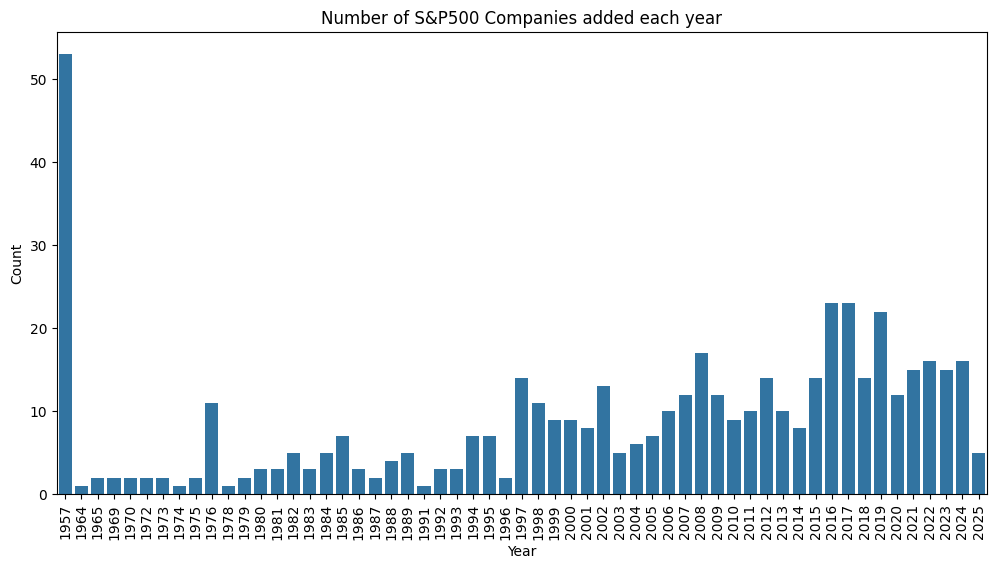

In [ ]:
# Построение гистограммы
plt.figure(figsize=(12, 6))
sns.countplot(data=df_added_sp500, x='year_added')

# Настройки графика
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Number of S&P500 Companies added each year')
plt.xticks(rotation=90)  # Поворот подписей оси X для удобства

plt.show()



In [ ]:
# Групуємо за роками і рахуємо кількість записів
year_counts = df_added_sp500['year_added'].value_counts().sort_values(ascending=False)

# Якщо потрібно саме у вигляді DataFrame:
year_counts_df = year_counts.reset_index()
year_counts_df.columns = ['year_added', 'count']

print(year_counts)

year_added
1957    53
2017    23
2016    23
2019    22
2008    17
2024    16
2022    16
2021    15
2023    15
2018    14
2015    14
1997    14
2012    14
2002    13
2007    12
2020    12
2009    12
1976    11
1998    11
2006    10
2011    10
2013    10
2010     9
1999     9
2000     9
2001     8
2014     8
1985     7
1994     7
1995     7
2005     7
2004     6
1989     5
2025     5
1982     5
2003     5
1984     5
1988     4
1993     3
1980     3
1992     3
1986     3
1983     3
1981     3
1996     2
1973     2
1987     2
1972     2
1969     2
1979     2
1965     2
1975     2
1970     2
1991     1
1974     1
1964     1
1978     1
Name: count, dtype: int64


In [ ]:
# Находим год с наибольшим количеством добавлений
higher_additions = year_counts_df.iloc[1]

# Выводим результат
print(
    f"The year with the highest number of S&P 500 additions is "
    f"{higher_additions['year_added']} with {higher_additions['count']} additions."
)

The year with the highest number of S&P 500 additions is 2017 with 23 additions.


Додатково: Скільки нинішніх акцій S&P 500 перебувають в індексі понад 20 років?

In [ ]:
# Парсимо таблицю з id = "changes" зі сторінки Wikipedia:
df_changes_sp500 = pd.read_html(
    io=wikipedia_url,
    attrs={"id": "changes"},
    parse_dates=[('Date', 'Date')],
)[0]
df_changes_sp500.head()

Date  Added                        Removed                      \
        Date Ticker               Security  Ticker            Security   
0 2025-05-19   COIN               Coinbase     DFS  Discover Financial   
1 2025-03-24   DASH               DoorDash     BWA          BorgWarner   
2 2025-03-24    TKO     TKO Group Holdings     TFX            Teleflex   
3 2025-03-24    WSM  Williams-Sonoma, Inc.      CE            Celanese   
4 2025-03-24    EXE          Expand Energy     FMC     FMC Corporation   

                                              Reason  
                                              Reason  
0  S&P 500 constituent Capital One Financial Corp...  
1                   Market capitalization change.[5]  
2                   Market capitalization change.[5]  
3                   Market capitalization change.[5]  
4                   Market capitalization change.[5]

In [ ]:
df_changes_sp500.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   (Date, Date)         372 non-null    datetime64[ns]
 1   (Added, Ticker)      357 non-null    object        
 2   (Added, Security)    357 non-null    object        
 3   (Removed, Ticker)    353 non-null    object        
 4   (Removed, Security)  353 non-null    object        
 5   (Reason, Reason)     372 non-null    object        
dtypes: datetime64[ns](1), object(5)
memory usage: 17.6+ KB


In [ ]:
df_changes_sp500 = df_changes_sp500[[("Date", "Date"), ("Added", "Ticker"), ("Removed", "Ticker")]]
# Перейменуємо стовпці для ясності
df_changes_sp500.columns = ["date", "add_symbol", "del_symbol"]
df_changes_sp500.to_csv('changes_sp500.csv', index=False)
df_changes_sp500.head()

,date,add_symbol,del_symbol
0,2025-05-19,COIN,DFS
1,2025-03-24,DASH,BWA
2,2025-03-24,TKO,TFX
3,2025-03-24,WSM,CE
4,2025-03-24,EXE,FMC


In [ ]:
df_changes_sp500.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        372 non-null    datetime64[ns]
 1   add_symbol  357 non-null    object        
 2   del_symbol  353 non-null    object        
dtypes: datetime64[ns](1), object(2)
memory usage: 8.8+ KB


In [ ]:
# Визначаємо поточні тікери
added_tickers = set(df_changes_sp500['add_symbol'].dropna())
removed_tickers = set(df_changes_sp500['del_symbol'].dropna())
current_tickers = added_tickers - removed_tickers
len(current_tickers)

230

In [ ]:
# Видаляємо пропуски
added_df = df_changes_sp500.dropna(subset=['add_symbol']).copy()

added_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 357 entries, 0 to 371
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        357 non-null    datetime64[ns]
 1   add_symbol  357 non-null    object        
 2   del_symbol  338 non-null    object        
dtypes: datetime64[ns](1), object(2)
memory usage: 11.2+ KB


In [ ]:
# Фільтруемо за current_tickers із 357 компаній
filtered_tickers = added_df[added_df['add_symbol'].isin(current_tickers)]
filtered_tickers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 232 entries, 0 to 371
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        232 non-null    datetime64[ns]
 1   add_symbol  232 non-null    object        
 2   del_symbol  223 non-null    object        
dtypes: datetime64[ns](1), object(2)
memory usage: 7.2+ KB


In [ ]:
# Фільтруємо ті, хто в індексі понад 20 років
today = pd.to_datetime('today')
threshold_date = today - pd.DateOffset(years=20)
long_term_members = filtered_tickers[filtered_tickers['date'] <= threshold_date]
long_term_members.head(10)

,date,add_symbol,del_symbol
355,2000-12-05,INTU,BS
361,2000-06-07,SBUX,SMS
363,1999-06-09,WLP,HPH
364,1999-04-12,ACT,NaN
365,1998-12-11,FSR,AN
366,1998-12-11,CCL,GRN
368,1997-06-17,CCI,USL
369,1994-09-30,NCC,MCK
370,1976-07-01,BUD,HNG
371,1976-07-01,DIS,AYE


In [ ]:
long_term_members.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 355 to 371
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        10 non-null     datetime64[ns]
 1   add_symbol  10 non-null     object        
 2   del_symbol  9 non-null      object        
dtypes: datetime64[ns](1), object(2)
memory usage: 320.0+ bytes


In [ ]:
# Кількість таких компаній
count_more_than_20_years = len(long_term_members)
print(
    f"There are {count_more_than_20_years} tickers with more than 20 years in the S&P 500."
)

There are 10 tickers with more than 20 years in the S&P 500.


### Question 2. [Macro] Indexes YTD (as of 1 May 2025)

**Скільки індексів (з 10) мають кращу дохідність з початку року, ніж американський (S&P 500) станом на 1 травня 2025 року?**

Використовуючи дані Yahoo Finance World Indices, порівняйте динаміку основних фондових індексів з початку року (1 січня по 1 травня 2025 року) для наступних країн:
* United States - S&P 500 (^GSPC)
* China - Shanghai Composite (000001.SS)
* Hong Kong - HANG SENG INDEX (^HSI)
* Australia - S&P/ASX 200 (^AXJO)
* India - Nifty 50 (^NSEI)
* Canada - S&P/TSX Composite (^GSPTSE)
* Germany - DAX (^GDAXI)
* United Kingdom - FTSE 100 (^FTSE)
* Japan - Nikkei 225 (^N225)
* Mexico - IPC Mexico (^MXX)
* Brazil - Ibovespa (^BVSP)

*Hint*: use start_date='2025-01-01' and end_date='2025-05-01' when downloading daily data in yfinance

Context:
> [Global Valuations: Who's Cheap, Who's Not?](https://simplywall.st/article/beyond-the-us-global-markets-after-yet-another-tariff-update) У статті йдеться про те, що "інші регіони можуть зростати швидше, ніж США, і вам потрібно диверсифікувати свою діяльність."

Reference: Yahoo Finance World Indices - https://finance.yahoo.com/world-indices/

In [ ]:
# Index tickers (Yahoo Finance format)
tickers = {
    "US": "^GSPC",
    "China": "000001.SS",
    "Hong Kong": "^HSI",
    "Australia": "^AXJO",
    "India": "^NSEI",
    "Canada": "^GSPTSE",
    "Germany": "^GDAXI",
    "UK": "^FTSE",
    "Japan": "^N225",
    "Mexico": "^MXX",
    "Brazil": "^BVSP"
}

indices = list(tickers.values())
start = "2025-01-01"
end = "2025-05-01"

# Download adjusted close prices
data = yf.download(tickers=indices, start=start, end=end, interval="1d")["Close"]
# data.to_csv('data.csv')

/tmp/ipython-input-19-3716390934.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers=indices, start=start, end=end, interval="1d")["Close"]
[*********************100%***********************]  11 of 11 completed


In [ ]:
# data = pd.read_csv('data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 86 entries, 2025-01-01 to 2025-04-30
Freq: B
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   000001.SS  78 non-null     float64
 1   ^AXJO      81 non-null     float64
 2   ^BVSP      81 non-null     float64
 3   ^FTSE      83 non-null     float64
 4   ^GDAXI     83 non-null     float64
 5   ^GSPC      81 non-null     float64
 6   ^GSPTSE    83 non-null     float64
 7   ^HSI       79 non-null     float64
 8   ^MXX       81 non-null     float64
 9   ^N225      78 non-null     float64
 10  ^NSEI      80 non-null     float64
dtypes: float64(11)
memory usage: 8.1 KB


In [ ]:
data.head()

Ticker,000001.SS,^AXJO,^BVSP,^FTSE,^GDAXI,^GSPC,^GSPTSE,^HSI,^MXX,^N225,^NSEI
Date,,,,,,,,,,,
2025-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23742.900391
2025-01-02,3262.561035,8201.200195,120125.0,8260.099609,20024.660156,5868.549805,24898.000000,19623.320312,49765.199219,NaN,24188.650391
2025-01-03,3211.429932,8250.500000,118533.0,8224.000000,19906.080078,5942.470215,25073.500000,19760.269531,48957.238281,NaN,24004.750000
2025-01-06,3206.923096,8288.500000,120022.0,8249.700195,20216.189453,5975.379883,24999.800781,19688.289062,49493.558594,39307.050781,23616.050781
2025-01-07,3229.644043,8285.099609,121163.0,8245.299805,20340.570312,5909.029785,24929.900391,19447.580078,50085.500000,40083.300781,23707.900391


In [ ]:
# Calculate YTD returns: (last_price - first_price) / first_price
ytd_indexes = (
    (data.bfill().iloc[-1] - data.bfill().iloc[0]) / data.bfill().iloc[0]) * 100

# Map tickers back to country names
country_ytd = {country: ytd_indexes[ticker]
                   for country, ticker in tickers.items()}

# Compare to US (S&P 500)
US_ytd = country_ytd["US"]
better_than_us = {country: ret for country, ret in country_ytd.items(
) if country != "US" and ret > US_ytd}

# Print summary
print(f"S&P 500 YTD return as of May 1, 2025: {US_ytd:.2f}%")
print("\nIndexes with better YTD returns than the US:")
for country, ret in better_than_us.items():
    print(f"- {country}: {ret:.2f}%")

print(
    f"\nAnswer: {len(better_than_us)} indexes had better YTD returns than the US.")

S&P 500 YTD return as of May 1, 2025: -5.10%

Indexes with better YTD returns than the US:
- China: 0.50%
- Hong Kong: 12.72%
- Australia: -0.91%
- India: 2.49%
- Canada: -0.23%
- Germany: 12.35%
- UK: 2.84%
- Mexico: 13.05%
- Brazil: 12.44%

Answer: 9 indexes had better YTD returns than the US.


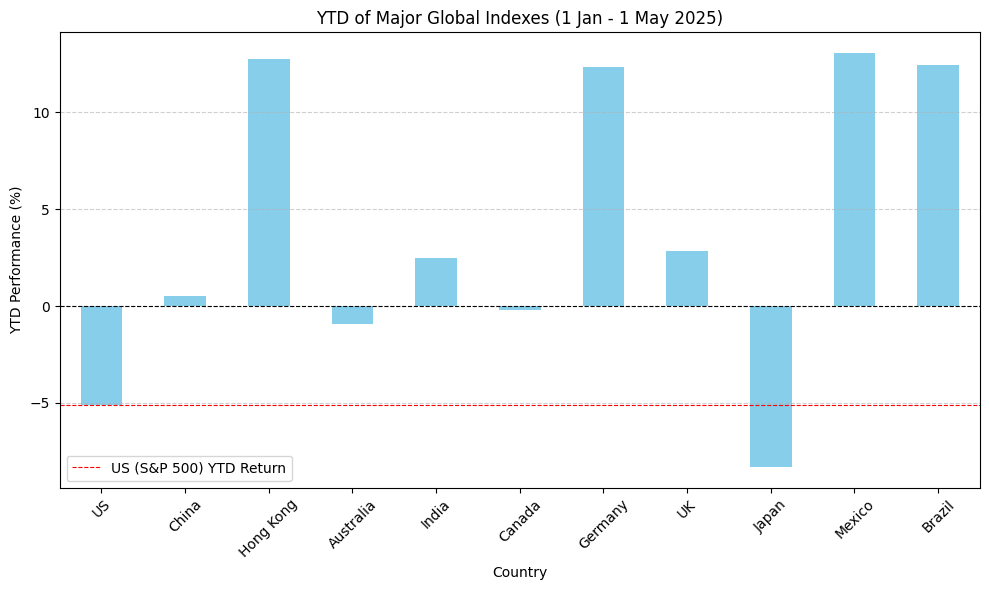

In [ ]:
# plot the YTD returns per country
plt.figure(figsize=(10, 6))
country_df = pd.Series(country_ytd)
country_df.plot(kind='bar', color='skyblue')

plt.axhline(y=US_ytd, color='red', linewidth=0.8, linestyle='--',
            label='US (S&P 500) YTD Return')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('YTD of Major Global Indexes (1 Jan - 1 May 2025)')
plt.xlabel('Country')
plt.ylabel('YTD Performance (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

*Additional*: Скільки з цих індексів мають кращу доходність, ніж S&P 500 за 3, 5 та 10 років? Чи бачите ви таку ж тенденцію?

Note: Для спрощення ігноруємо ефекти конвертації валют.

In [ ]:
# Define target periods
date_offsets = {
    "3Y": pd.to_datetime("2021-12-31"),
    "5Y": pd.to_datetime("2019-12-31"),
    "10Y": pd.to_datetime("2014-12-31")
}
end_date = pd.to_datetime("2025-01-01")
date_offsets

{'3Y': Timestamp('2021-12-31 00:00:00'),
 '5Y': Timestamp('2019-12-31 00:00:00'),
 '10Y': Timestamp('2014-12-31 00:00:00')}

In [ ]:
# Store results
results = []

for country, symbol in tickers.items():
    data = {'Country': country}
    try:
        # Download data (with small buffer around the 10-year mark)
        ticker = yf.Ticker(symbol)
        hist = ticker.history(
            start=date_offsets["10Y"] - timedelta(days=1),
            end=end_date + timedelta(days=1),
            interval='1d'
        )
        # print(hist)
        # Use naive datetime (remove timezone if present)
        hist.index = hist.index.tz_localize(None)
        hist = hist[['Close']].dropna()

        # Get latest price up to Jan 1, 2025
        price_today = hist[hist.index <= end_date].iloc[-1]['Close']

        # Get returns for each period
        for label, date in date_offsets.items():
            past_price = hist[hist.index <= date].iloc[-1]['Close']
            data[f'{label}TD'] = (price_today / past_price - 1) * 100
    except Exception as e:
        print(f"Error with {symbol}: {e}")
        data[f'3YTD'] = data[f'5YTD'] = data[f'10YTD'] = None
    results.append(data)

In [ ]:
# Convert to DataFrame
returns_df = pd.DataFrame(results)
returns_df

,Country,3YTD,5YTD,10YTD
0,US,23.403431,82.049840,185.668569
1,China,-7.913036,9.889398,3.619710
2,Hong Kong,-14.265184,-28.839563,-15.018360
3,Australia,9.597561,22.067294,50.787287
4,India,36.814745,95.118524,186.656523
5,Canada,16.515726,44.917776,68.994148
6,Germany,25.334061,50.268895,103.039514
7,UK,10.677771,8.360735,24.472668
8,Japan,38.562585,68.640070,128.611919
9,Mexico,-7.056504,13.716376,14.758401


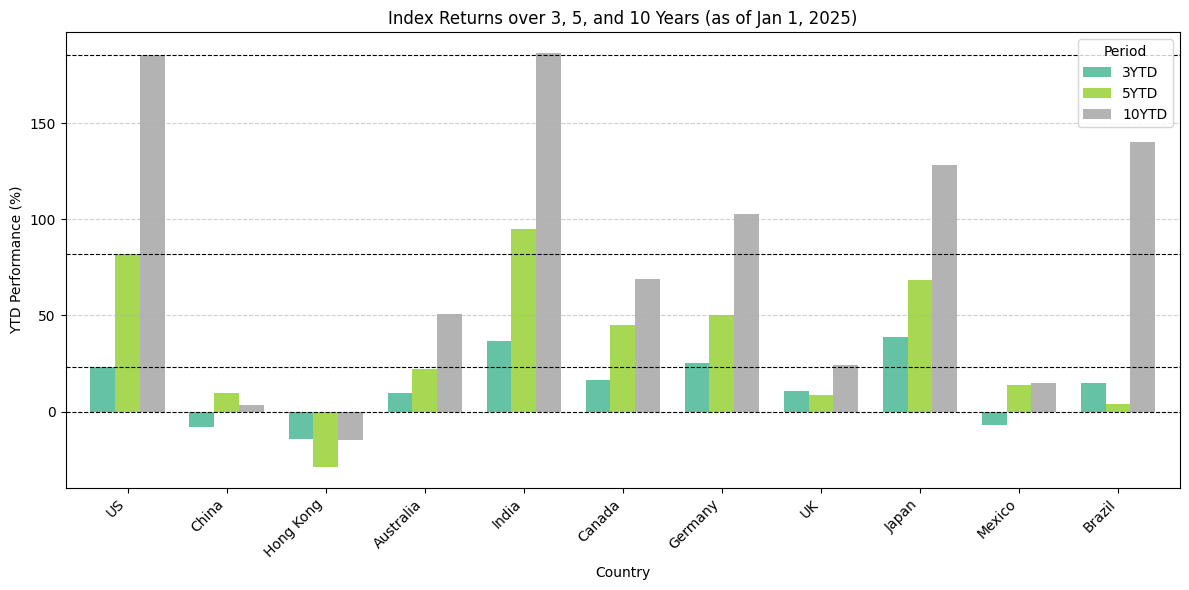

In [ ]:
# Set index names for x-axis labels
returns_df_plot = returns_df.set_index('Country')

# Plot setup
fig, ax = plt.subplots(figsize=(12, 6))
returns_df_plot[['3YTD', '5YTD', '10YTD']].plot(
    kind='bar',
    ax=ax,
    width=0.75,
    colormap='Set2'
)

# Titles and labels
plt.title("Index Returns over 3, 5, and 10 Years (as of Jan 1, 2025)")
plt.ylabel("YTD Performance (%)")
plt.xlabel("Country")

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axhline(y=23.4, color='black', linewidth=0.8, linestyle='--')
plt.axhline(y=82.04, color='black', linewidth=0.8, linestyle='--')
plt.axhline(y=185.66, color='black', linewidth=0.8, linestyle='--')

plt.xticks(rotation=45, ha='right')
plt.legend(title="Period")
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.show()

### Question 3. [Index] S&P 500 Market Corrections Analysis


**Розрахуйте медіанну тривалість (у днях) значних ринкових корекцій індексу S&P 500.**

Для цієї задачі визначимо корекцію як подію, коли фондовий індекс падає на **більше ніж на 5%** від найближчого історичного максимуму.

Крок за кроком:
1. Завантажте історичні дані S&P 500 (1950 - теперішній час) за допомогою yfinance
2. Визначте історичні максимуми (коли ціна перевищує всі попередні ціни)
3. Для кожної пари послідовних історичних максимумів знайдіть мінімальну ціну між ними
4. Обчислити відсоток просадки: (високий - низький) / високий × 100
5. Фільтр для корекцій з просадкою не менше 5%
6. Розрахуйте тривалість у днях для кожного періоду корекції
7. Визначте 25-й, 50-й (медіана) та 75-й процентилі для тривалості корекції

*Context:*
> * Інвестори часто задаються питанням про типову тривалість ринкових корекцій, коли вирішують, "коли купувати падіння"." ([Reddit discussion](https://www.reddit.com/r/investing/comments/1jrqnte/when_are_you_buying_the_dip/?rdt=64135)).

> * [A Wealth of Common Sense - How Often Should You Expect a Stock Market Correction?](https://awealthofcommonsense.com/2022/01/how-often-should-you-expect-a-stock-market-correction/)

*Hint (use this data to compare with your results)*: Ось список 10 найбільших корекцій за просадкою:
* 2007-10-09 to 2009-03-09: 56.8% drawdown over 517 days
* 2000-03-24 to 2002-10-09: 49.1% drawdown over 929 days
* 1973-01-11 to 1974-10-03: 48.2% drawdown over 630 days
* 1968-11-29 to 1970-05-26: 36.1% drawdown over 543 days
* 2020-02-19 to 2020-03-23: 33.9% drawdown over 33 days
* 1987-08-25 to 1987-12-04: 33.5% drawdown over 101 days
* 1961-12-12 to 1962-06-26: 28.0% drawdown over 196 days
* 1980-11-28 to 1982-08-12: 27.1% drawdown over 622 days
* 2022-01-03 to 2022-10-12: 25.4% drawdown over 282 days
* 1966-02-09 to 1966-10-07: 22.2% drawdown over 240 days

In [ ]:
# Завантаження щоденних даних для S&P 500 за діапазон дат
sp500_daily = yf.download(tickers = "^GSPC",
                          start = "1950-01-01",
                          end = "2025-05-01",
                          interval = "1d")['Close']

sp500_daily = sp500_daily.reset_index()
sp500_daily.columns = ["date", "close"]
sp500_daily.head()

/tmp/ipython-input-28-2360061662.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500_daily = yf.download(tickers = "^GSPC",
[*********************100%***********************]  1 of 1 completed


,date,close
0,1950-01-03,16.66
1,1950-01-04,16.85
2,1950-01-05,16.93
3,1950-01-06,16.98
4,1950-01-09,17.08


In [ ]:
sp500_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18952 entries, 0 to 18951
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    18952 non-null  datetime64[ns]
 1   close   18952 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 296.3 KB


In [ ]:
# All time high points(ATH):
sp500_daily['ATH'] = sp500_daily.close.cummax()
high_points = sp500_daily[sp500_daily.close == sp500_daily['ATH']].copy().reset_index()
high_points.head(10)

,index,date,close,ATH
0,0,1950-01-03,16.660000,16.660000
1,1,1950-01-04,16.850000,16.850000
2,2,1950-01-05,16.930000,16.930000
3,3,1950-01-06,16.980000,16.980000
4,4,1950-01-09,17.080000,17.080000
5,6,1950-01-11,17.090000,17.090000
6,22,1950-02-02,17.230000,17.230000
7,23,1950-02-03,17.290001,17.290001
8,24,1950-02-06,17.320000,17.320000
9,42,1950-03-06,17.320000,17.320000


In [ ]:
# Знайдемо мінімальні значення між кожною парою ATH
min_between_highs = []

for i in range(len(high_points) - 1):
    start_idx = high_points.loc[i, 'index']
    end_idx = high_points.loc[i+1, 'index']

    # print(start_idx, end_idx)
    if end_idx - start_idx > 1:
        between = sp500_daily.loc[start_idx + 1:end_idx - 1]
        min_row = between.loc[between.close.idxmin()]

        min_between_highs.append({
            'from_date': sp500_daily.loc[start_idx, 'date'],
            'to_date': min_row.date,
            'high_price': sp500_daily.loc[start_idx, 'close'],
            'min_price': min_row.close,
            'min_date': min_row.date
        })

# Перетворимо у DataFrame
min_df = pd.DataFrame(min_between_highs)
# min_df.head()

# Обчислимо drawdown у відсотках
min_df['drawdown%'] = (min_df['high_price'] - min_df['min_price']) / min_df['high_price'] * 100

# Відфільтруємо лише ті, що мають drawdown >= 5%
corrections = min_df[min_df['drawdown%'] >= 5].copy()

# Обчислимо тривалість drawdown у днях
corrections['durations_days'] = (corrections['to_date'] - corrections['from_date']).dt.days

# Обчислимо квартилі тривалості drawdown
percentiles = corrections['durations_days'].quantile([0.25, 0.5, 0.75]).to_dict()

# Топ-10 найбільших drawdown
top_drawdowns = corrections.sort_values(by='drawdown%', ascending=False).head(10)

# Виведемо основні результати
print(top_drawdowns[['from_date', 'to_date', 'drawdown%', 'durations_days']])


     from_date    to_date  drawdown%  durations_days
448 2007-10-09 2009-03-09  56.775388             517
443 2000-03-24 2002-10-09  49.146948             929
206 1973-01-11 1974-10-03  48.203593             630
193 1968-11-29 1970-05-26  36.061641             543
574 2020-02-19 2020-03-23  33.924960              33
292 1987-08-25 1987-12-04  33.509515             101
133 1961-12-12 1962-06-26  27.973568             196
219 1980-11-28 1982-08-12  27.113582             622
620 2022-01-03 2022-10-12  25.425097             282
176 1966-02-09 1966-10-07  22.177335             240


In [ ]:
top_drawdowns.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 448 to 176
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   from_date       10 non-null     datetime64[ns]
 1   to_date         10 non-null     datetime64[ns]
 2   high_price      10 non-null     float64       
 3   min_price       10 non-null     float64       
 4   min_date        10 non-null     datetime64[ns]
 5   drawdown%       10 non-null     float64       
 6   durations_days  10 non-null     int64         
dtypes: datetime64[ns](3), float64(3), int64(1)
memory usage: 640.0 bytes


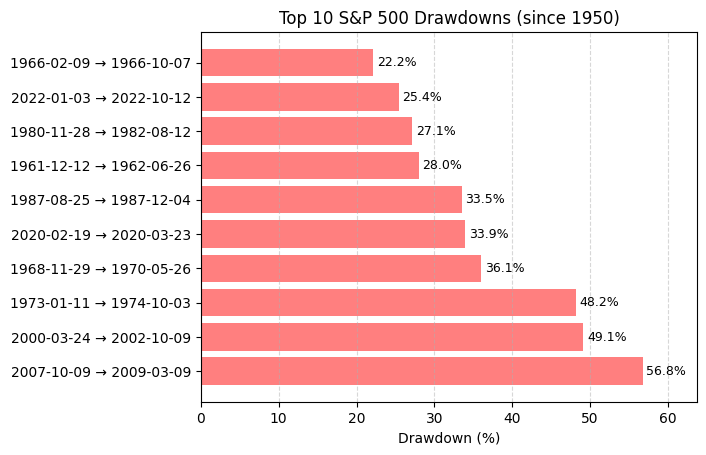

In [ ]:
# top_drawdowns = ath_dips_df.sort_values('Drawdown_%', ascending=False).head(10)

# plt.figure(figsize=(10, 6))
plt.barh(
    [f"{row.from_date.date()} → {row.to_date.date()}" for row in top_drawdowns.itertuples()],
    top_drawdowns['drawdown%'],
    color='#FF7F7F'
)

# Добавление текста справа от каждой полоски
for i, (value, label) in enumerate(zip(top_drawdowns['drawdown%'], top_drawdowns.itertuples())):
    plt.text(
        value + 0.5,  # немного правее конца бара
        i,            # позиция по y
        f"{value:.1f}%",  # форматированный текст (например, 23.4%)
        va='center',
        fontsize=9
    )

plt.title("Top 10 S&P 500 Drawdowns (since 1950)")
plt.xlabel("Drawdown (%)")
# plt.gca().invert_yaxis()
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, top_drawdowns['drawdown%'].max() + 7)  # немного больше максимума

plt.show()

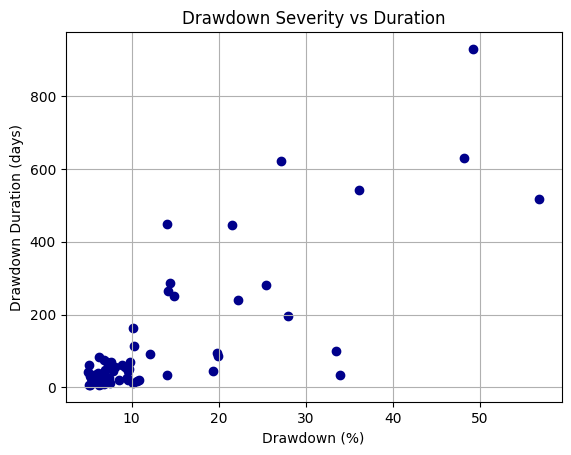

In [ ]:
plt.scatter( corrections['drawdown%'], corrections['durations_days'], color='darkblue')
plt.ylabel("Drawdown Duration (days)")
plt.xlabel("Drawdown (%)")
plt.title("Drawdown Severity vs Duration")
plt.grid(True)
plt.show()

In [ ]:
percentiles

{0.25: 21.5, 0.5: 39.0, 0.75: 89.0}

In [ ]:
print(f"The median is {percentiles[0.5]}")

The median is 39.0


### Question 4.  [Stocks] Earnings Surprise Analysis for Amazon (анализ того, насколько прибыль Amazon оказалась выше или ниже, чем ожидали эксперты)


**Розрахуйте медіанну 2-денну відсоткову зміну цін акцій після днів позитивних несподіваних прибутків.**

Крок за кроком:
1. Завантажте дані про прибутки з CSV ([ha1_Amazon.csv](https://github.com/DataTalksClub/stock-markets-analytics-zoomcamp/blob/main/cohorts/2025/ha1_Amazon.csv)), що містять дати отримання прибутку, розрахункові значення EPS та фактичні EPS. Переконайтеся, що ви використовуєте правильний роздільник для читання даних, як у цій команді
```python
 pandas.read_csv("ha1_Amazon.csv", delimiter=';')
```
2. Завантажте повні історичні цінові дані за допомогою yfinance
3. Обчислити 2-денні відсоткові зміни для всіх історичних дат: для кожної послідовності з 3 послідовних торгових днів (День 1, День 2, День 3) обчислити *return* як Close_Day3 / Close_Day1 - 1. (Припустимо, що День 2 може відповідати оголошенню про прибутки).
4. Визначте позитивні несподіванки в доходах (where "actual EPS > estimated EPS"). Обидва поля повинні бути присутніми у файлі. Ви повинні отримати 36 точок даних для подальшого використання в описовому аналізі (медіана).
6. Розрахуйте 2-денні відсоткові зміни після позитивних несподіванок у доходах. Покажіть свою відповідь у % (найближче число до 2-ї цифри): *повернути* * 100.0
7. (За бажанням) Порівняйте середню 2-денну зміну у відсотках для позитивних несподіванок з усіма історичними датами. Чи бачите ви різницю?

Context: Объявления о прибылях, особенно если они превышают ожидания аналитиков, могут существенно повлиять на цены акций в краткосрочной перспективе.

Reference: Yahoo Finance earnings calendar - https://finance.yahoo.com/calendar/earnings?symbol=AMZN

*Additional*: Есть ли корреляция между величиной неожиданности прибыли и реакцией цены акций? По-разному ли реагирует рынок на неожиданности прибыли во время бычьего и медвежьего рынков?)


In [ ]:
AMZN_df = pd.read_csv("ha1_Amazon.csv", delimiter=';').dropna(subset=["Earnings Date"])

In [ ]:
AMZN_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 116 entries, 0 to 115
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Symbol         116 non-null    object
 1   Company        116 non-null    object
 2   Earnings Date  116 non-null    object
 3   EPS Estimate   116 non-null    object
 4   Reported EPS   116 non-null    object
 5   Surprise (%)   116 non-null    object
dtypes: object(6)
memory usage: 6.3+ KB


In [ ]:
# Преобразуем 'Surprise (%)' в число (float)
AMZN_df["Reported EPS"] = pd.to_numeric(AMZN_df["Reported EPS"], errors="coerce")
AMZN_df["EPS Estimate"] = pd.to_numeric(AMZN_df["EPS Estimate"], errors="coerce")
AMZN_df["Surprise (%)"] = pd.to_numeric(AMZN_df["Surprise (%)"], errors="coerce")

In [ ]:
# Преобразуем 'Earnings Date' в Timestamp
AMZN_df['Earnings Date'] = AMZN_df['Earnings Date'].str.replace(r"\s+at.*", "", regex=True)
AMZN_df['Earnings Date'] = pd.to_datetime(AMZN_df['Earnings Date'])

In [ ]:
AMZN_df.head(20)

,Symbol,Company,Earnings Date,EPS Estimate,Reported EPS,Surprise (%)
0,AMZN,Amazon.com Inc,2026-04-29,NaN,NaN,NaN
1,AMZN,Amazon.com Inc,2026-02-04,NaN,NaN,NaN
2,AMZN,Amazon.com Inc,2025-10-29,NaN,NaN,NaN
3,AMZN,Amazon.com Inc,2025-07-30,NaN,NaN,NaN
4,AMZN,"Amazon.com, Inc.",2025-05-01,1.36,1.59,16.74
5,AMZN,"Amazon.com, Inc.",2025-02-06,1.49,1.86,24.47
6,AMZN,"Amazon.com, Inc.",2024-10-31,1.14,1.43,25.17
7,AMZN,"Amazon.com, Inc.",2024-08-01,1.03,1.26,22.58
8,AMZN,"Amazon.com, Inc.",2024-04-30,0.83,0.98,17.91
9,AMZN,"Amazon.com, Inc.",2024-02-01,0.80,1.00,24.55


In [ ]:
# Step 2: Download Amazon historical price data
AMZN_hist = yf.Ticker("AMZN").history(start="1997-01-01", end="2025-05-01")["Close"]
AMZN_hist = AMZN_hist.reset_index()
AMZN_hist.columns = ["date", "close"]
# Step 3
AMZN_hist["close_day1"] = AMZN_hist["close"]
AMZN_hist["close_day3"] = AMZN_hist["close"].shift(-2)
AMZN_hist["2_day_return"] = (AMZN_hist["close_day3"] / AMZN_hist["close_day1"]) - 1

In [ ]:
AMZN_hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7034 entries, 0 to 7033
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype                           
---  ------        --------------  -----                           
 0   date          7034 non-null   datetime64[ns, America/New_York]
 1   close         7034 non-null   float64                         
 2   close_day1    7034 non-null   float64                         
 3   close_day3    7032 non-null   float64                         
 4   2_day_return  7032 non-null   float64                         
dtypes: datetime64[ns, America/New_York](1), float64(4)
memory usage: 274.9 KB


<Axes: title={'center': 'відносна зміна ціни за два дні'}>

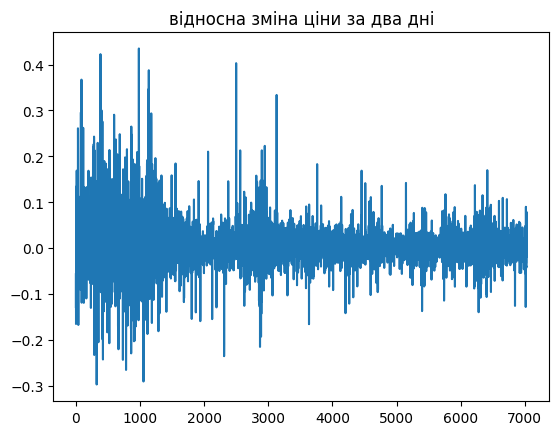

In [ ]:
AMZN_hist['2_day_return'].plot.line(title="відносна зміна ціни за два дні")

In [ ]:
filtered_df = AMZN_df[AMZN_df['Reported EPS'] > AMZN_df['EPS Estimate']]

filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37 entries, 4 to 81
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Symbol         37 non-null     object        
 1   Company        37 non-null     object        
 2   Earnings Date  37 non-null     datetime64[ns]
 3   EPS Estimate   37 non-null     float64       
 4   Reported EPS   37 non-null     float64       
 5   Surprise (%)   37 non-null     float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 2.0+ KB


In [ ]:
AMZN_hist['date'] = AMZN_hist['date'].dt.tz_localize(None)
amazon_positive = pd.merge(AMZN_hist,
                           filtered_df[["Earnings Date", "Surprise (%)"]],
                           left_on = 'date',
                           right_on='Earnings Date',
                           how='inner')
amazon_positive

,date,close,close_day1,close_day3,2_day_return,Earnings Date,Surprise (%)
0,2006-02-02,2.137000,2.137000,1.897500,-0.112073,2006-02-02,120.86
1,2008-07-23,3.527000,3.527000,3.915500,0.110150,2008-07-23,42.09
2,2009-01-29,2.500000,2.500000,3.057500,0.223000,2009-01-29,33.20
3,2010-10-21,8.248500,8.248500,8.450000,0.024429,2010-10-21,7.28
4,2011-01-27,9.222500,9.222500,8.482000,-0.080293,2011-01-27,3.03
5,2012-01-31,9.722000,9.722000,9.086000,-0.065419,2012-01-31,127.00
6,2015-01-29,15.589000,15.589000,18.223499,0.168997,2015-01-29,168.18
7,2015-07-23,24.108999,24.108999,26.570499,0.102099,2015-07-23,237.28
8,2015-10-22,28.195499,28.195499,30.430500,0.079268,2015-10-22,225.37
9,2016-04-28,30.100000,30.100000,34.192501,0.135963,2016-04-28,81.42


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=amazon_positive)

https://docs.google.com/spreadsheets/d/1iFeNjqonbyPbP-8WAdxe7Te-Xzcw2wuVjLon5Hr76Qc/edit#gid=0


In [ ]:
amazon_positive['2_day_return'].mean().round(3)*100

np.float64(1.9)

<Axes: title={'center': 'відносна зміна ціни за два дні Reported EPS > EPS Estimate'}>

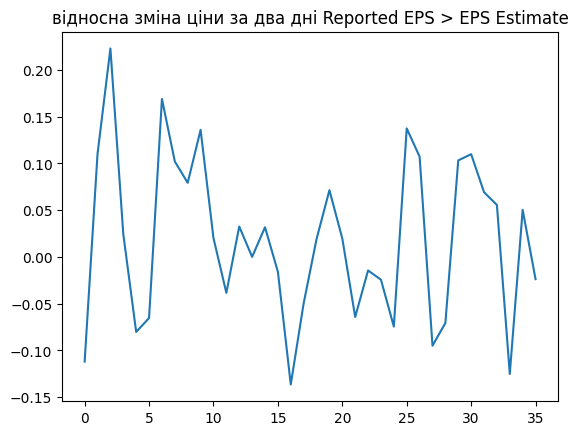

In [ ]:
amazon_positive['2_day_return'].plot.line(title="відносна зміна ціни за два дні Reported EPS > EPS Estimate")

<Axes: title={'center': 'відносна зміна ціни за два дні Reported EPS < EPS Estimate'}>

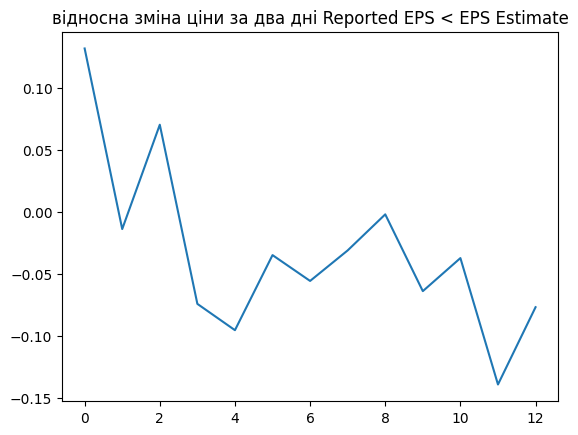

In [ ]:
filtered_df = AMZN_df[AMZN_df['Reported EPS'] < AMZN_df['EPS Estimate']]

amazon_negative = pd.merge(AMZN_hist,
                           filtered_df[["Earnings Date", "Surprise (%)"]],
                           left_on = 'date',
                           right_on='Earnings Date',
                           how='inner')

amazon_negative['2_day_return'].plot.line(title="відносна зміна ціни за два дні Reported EPS < EPS Estimate")